# Fluid-Like Vector Fields and Advection

This notebook builds a smooth incompressible-like vector field on $[0,1]^2$ and advects particles.
The smoothing scale is explicitly set near $\sigma\approx 0.05$ in physical coordinates, as requested.


## Vector field generation with Gaussian smoothing scale 0.05


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

from scipy.ndimage import gaussian_filter

OUT = Path("python/fluids"); OUT.mkdir(parents=True, exist_ok=True)
n = 170
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
sigma_phys = 0.05
sigma_px = sigma_phys / dx

psi0 = rng.normal(size=(n, n))
psi = gaussian_filter(psi0, sigma=sigma_px, mode="reflect")
u = np.gradient(psi, dx, axis=0)
v = -np.gradient(psi, dx, axis=1)
u /= np.std(u) + 1e-12
v /= np.std(v) + 1e-12
u *= 0.09
v *= 0.09


## Streamlines and particle advection


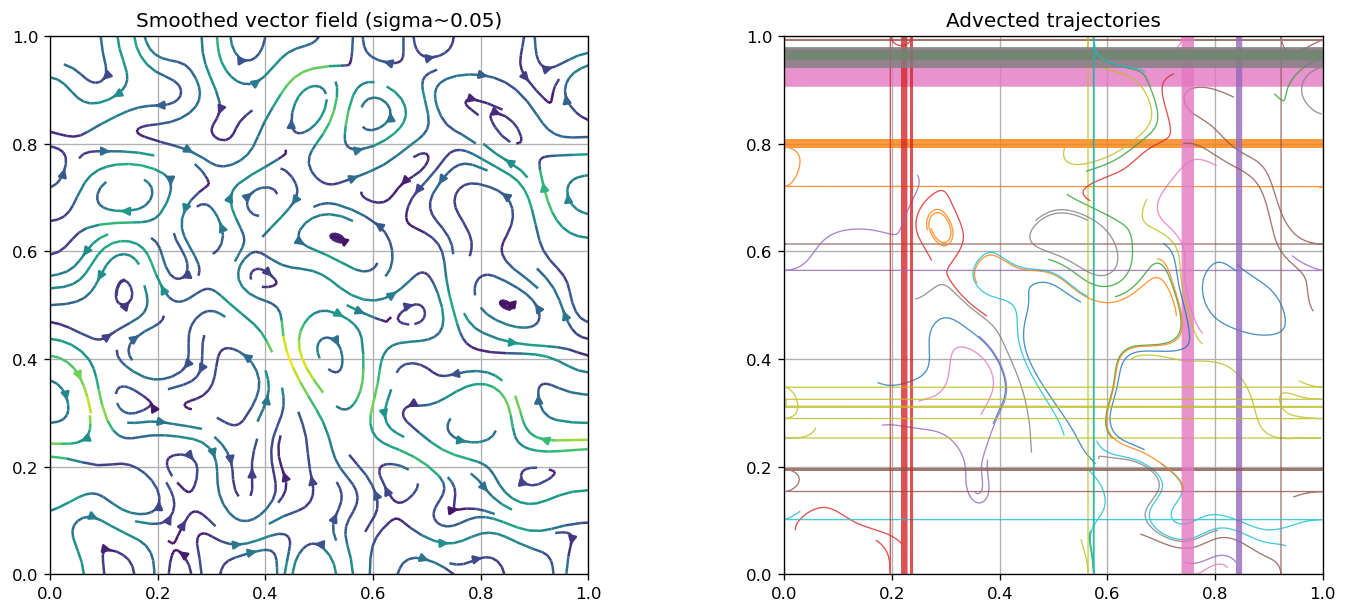

In [2]:
m = 220
P = rng.uniform(0.0, 1.0, size=(m, 2))
steps = 220
dt = 0.018
traj = np.zeros((steps + 1, m, 2))
traj[0] = P

def sample_field(P):
    ix = np.clip((P[:,0] / dx).astype(int), 0, n - 2)
    iy = np.clip((P[:,1] / dx).astype(int), 0, n - 2)
    fx = (P[:,0] - x[ix]) / dx
    fy = (P[:,1] - y[iy]) / dx
    uu = (1-fx)*(1-fy)*u[iy,ix] + fx*(1-fy)*u[iy,ix+1] + (1-fx)*fy*u[iy+1,ix] + fx*fy*u[iy+1,ix+1]
    vv = (1-fx)*(1-fy)*v[iy,ix] + fx*(1-fy)*v[iy,ix+1] + (1-fx)*fy*v[iy+1,ix] + fx*fy*v[iy+1,ix+1]
    return np.c_[uu, vv]

for k in range(steps):
    V = sample_field(P)
    P = (P + dt * V) % 1.0
    traj[k + 1] = P

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.0), constrained_layout=True)
axes[0].streamplot(x, y, u, v, density=1.1, color=np.hypot(u, v), cmap="viridis")
axes[0].set_title("Smoothed vector field (sigma~0.05)")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")

sel = np.arange(40)
for i in sel:
    axes[1].plot(traj[:, i, 0], traj[:, i, 1], lw=0.8, alpha=0.8)
axes[1].set_title("Advected trajectories")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1); axes[1].set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
